# 05 — D5 `markov_switching_var` (Markov-Switching econométrico · familia F4)

**Baseline econométrico interpretable**, en la tradición de Hamilton (1989). Un *Markov-Switching model* es un modelo de regresión en el que un régimen latente —gobernado por una cadena de Markov— **cambia los parámetros de la ecuación**: aquí, sobre el **retorno del S&P 500**, el régimen modula a la vez la **media** y la **varianza**. El régimen de **alta varianza** (media baja o negativa) es la *crisis/estrés*; el de baja varianza, la *calma*. Implementación: `statsmodels.MarkovRegression(switching_variance=True, trend='c')`. A diferencia del HMM multivariante D4, D5 no es una "caja"; sus parámetros (media, varianza y persistencia por régimen) se leen directamente y tienen interpretación económica.

**Por qué D5 es univariante y por qué importa el etiquetado robusto.** D5 modela SOLO el retorno del propio índice —no la correlación cross-asset que sí veía D4—. Como el régimen separa principalmente por **varianza** y no por el signo del retorno, es exactamente el caso en que un etiquetado ingenuo ("la primera columna es crisis") podría **INVERTIR** crisis y calma. Para blindarlo pasamos `market_returns` (retorno log del S&P 500) **explícito** a `walk_forward` y `evaluate`, y verificamos que crisis = alta varianza.

**Causalidad — probabilidades FILTRADAS, no smoothed.** `MarkovRegression` ofrece dos probabilidades de régimen: la **filtrada** P(S_t | y≤t), que solo usa el pasado (causal), y la **suavizada** P(S_t | y₁..T), que usa todo el histórico incluido el futuro (look-ahead). Para la evaluación online se usan las **filtradas**. Como en walk-forward no se puede reestimar el modelo bloque a bloque, `predict_online`/`predict_proba` corren un **forward filter gaussiano univariante propio** (con μ_k, σ²_k y matriz de transición congelados del train) sobre `burn-in de train + bloque`, devolviendo solo el bloque: cero look-ahead intra-bloque. Las suavizadas se reservan para una comparación IN-SAMPLE, marcada NO causal.

**Ventana LARGA.** El retorno del S&P 500 existe desde **1985**; con train inicial de ~8 años, **2008 y 2011 SÍ son evaluables out-of-sample** —a diferencia de D4, atado a features que arrancan en 2007—. Es la ventaja estructural de un detector univariante con histórico largo.

**Hipótesis CHECKPOINT 2 (D5):** *baseline econométrico interpretable; capta calma/estrés; punto ciego en crisis rápidas; univariante no ve correlación cross-asset; gaussiano insuficiente para colas.* Se verifica al final.

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import evaluation as ev
from detectors.markov_switching_var import MarkovSwitchingVar

raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
print('Panel crudo:', raw.shape, '|', raw.index.min().date(), '->', raw.index.max().date())
print('S&P 500 primer dato válido:', raw['SP500'].first_valid_index().date())

Panel crudo: (10591, 9) | 1985-01-02 -> 2026-06-16
S&P 500 primer dato válido: 1985-01-02


## 1. Endog: retorno log del S&P 500 (histórico largo desde 1985)

`SP500_ret` = retorno log del S&P 500, y cumple tres papeles a la vez: (a) es el **endog** del Markov-Switching —la serie cuyos parámetros conmutan—, (b) es el `market_returns` que da el **etiquetado económico** robusto (0=calma..1=crisis), y (c) es la base de la `p_crisis`. El retorno es causal por construcción —diferencia de log-precios; en t solo usa precios ≤ t—. La columna se llama exactamente `SP500_ret`, nombre reconocido por el núcleo en `_RETURN_COLS`, de modo que el etiquetado económico NO cae al fallback que "PUEDE INVERTIR" crisis y calma: una salvaguarda explícita contra la inversión de régimen.

In [2]:
spx_ret = np.log(raw['SP500'] / raw['SP500'].shift(1)).rename('SP500_ret')
X = pd.DataFrame({'SP500_ret': spx_ret}).dropna()
X.index = pd.to_datetime(X.index); X = X.sort_index()
mr = X['SP500_ret']   # market_returns explícito (retorno log S&P 500)
print('X (histórico largo):', X.shape, '|', X.index.min().date(), '->', X.index.max().date())
print('retorno diario: media=%.4f  std=%.4f  kurtosis=%.1f' % (mr.mean(), mr.std(), mr.kurtosis()))
X.head(3)

X (histórico largo): (10294, 1) | 1985-01-03 -> 2026-06-12
retorno diario: media=0.0004  std=0.0115  kurtosis=25.6


,SP500_ret
date,
1985-01-03,-0.004849
1985-01-04,-0.005423
1985-01-07,0.003416


## 2. Ajuste in-sample, parámetros por régimen y verificación crisis = ALTA varianza

Ajustamos sobre TODO el histórico solo para **inspeccionar los parámetros** (la evaluación honesta es el walk-forward de la §4). Imprimimos la media y la **varianza por estado en orden canónico** y verificamos lo esencial para la interpretabilidad del modelo: que el estado de crisis (canónico `n−1`) es el de **mayor varianza** y no está invertido. Como guinda, contrastamos el `predict_proba` del forward filter propio contra las `filtered_marginal_probabilities` de statsmodels: deben coincidir hasta precisión numérica, lo que valida que nuestro filtrado causal reproduce exactamente el de la librería.

In [3]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    det = MarkovSwitchingVar(n_states=2).fit(X)

print('crisis_state canónico =', det.crisis_state, '| n_states =', det.n_states)
print('bibliografía:', det.bibliography)
means_c = det.means_canonical(); vars_c = det.variances_canonical()
print('\n--- Parámetros por estado (orden canónico 0=calma .. n-1=crisis) ---')
for i in range(det.n_states):
    tag = 'CRISIS' if i == det.crisis_state else 'calma '
    print(f'  estado {i} [{tag}]: media={means_c[i]:+.4f}   varianza={vars_c[i]:.4f}')
crisis_is_high_var = np.isclose(vars_c[det.crisis_state], vars_c.max())
print('\nVERIFICACIÓN crisis = ALTA varianza:', crisis_is_high_var)
assert crisis_is_high_var, 'FALLO: el estado crisis NO es el de mayor varianza (invertido)'
# Validación del filtrado propio: debe coincidir con statsmodels in-sample (sin burn-in).
diff = np.max(np.abs(det.predict_proba(X) - det.insample_proba('filtered')))
print('max|forward-filter propio - statsmodels filtered| =', f'{diff:.2e}', '(≈0 ⇒ OK)')

crisis_state canónico = 1 | n_states = 2
bibliografía: ['hamilton1989', 'ms_kim1994', 'ms_guidolin2011', 'ms_kimnelson1999']

--- Parámetros por estado (orden canónico 0=calma .. n-1=crisis) ---
  estado 0 [calma ]: media=+0.0837   varianza=0.4963
  estado 1 [CRISIS]: media=-0.1148   varianza=3.8833

VERIFICACIÓN crisis = ALTA varianza: True


max|forward-filter propio - statsmodels filtered| = 1.19e-13 (≈0 ⇒ OK)


## 3. Selección del número de estados por AIC/BIC (k=2 vs k=3)

Ajustamos también k=3 y comparamos AIC y BIC (criterios de información: menor es mejor; el BIC penaliza más los parámetros). Reportamos qué *k* prefiere cada criterio. El detector que se evalúa es **k=2**, el baseline interpretable calma/crisis comparable con D4; k=3 se documenta como referencia —un tercer régimen de varianza intermedia que separa "corrección" de "crisis sistémica"—, no como el modelo desplegado.

In [4]:
rows = []
fits = {}
for k in (2, 3):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        d = MarkovSwitchingVar(n_states=k, search_reps=20).fit(X)
    fits[k] = d
    rows.append({'k': k, 'logL': d.score(X), 'n_params': d.n_parameters(),
                 'AIC': d.aic(X), 'BIC': d.bic(X)})
sel = pd.DataFrame(rows).set_index('k')
print(sel.round(1))
print('\nk* por AIC =', int(sel['AIC'].idxmin()), ' | k* por BIC =', int(sel['BIC'].idxmin()))
print('\nVarianzas por estado (canónico) para cada k:')
for k in (2, 3):
    print(f'  k={k}:', np.round(fits[k].variances_canonical(), 4))

      logL  n_params      AIC      BIC
k                                     
2 -13984.2         6  27980.3  28023.8
3 -13568.3        12  27160.6  27247.4

k* por AIC = 3  | k* por BIC = 3

Varianzas por estado (canónico) para cada k:
  k=2: [0.4963 3.8835]
  k=3: [0.3241 1.3212 9.3394]


## 4. Walk-forward CAUSAL (cubre 2008 y 2011 OOS)

`ev.walk_forward` reentrena el MS en ventanas crecientes y predice el siguiente bloque usando solo el pasado. Dentro de cada bloque, la predicción NO reestima el modelo: aplica el **forward filter univariante propio** con los parámetros congelados del train y un burn-in de train ⇒ probabilidades **FILTRADAS** causales, sin look-ahead intra-bloque. `market_returns` re-fija el orden económico en cada fold.

**Coste y elección de `step=63`.** El refit del MS es caro (reestimación por fold; con ventana expanding los folds tardíos ajustan sobre 10 000+ obs). Se usa **step trimestral** (63 días, ~131 reestimaciones en vez de ~394): los regímenes de varianza son persistentes, así que un refit trimestral es adecuado y preserva la ventana larga que hace evaluables 2008 y 2011. El filtrado dentro de cada bloque sigue siendo **diario y causal**.

In [5]:
factory = lambda: MarkovSwitchingVar(n_states=2)
# step=63 (refit trimestral): el MS reestima ~131 veces en vez de ~394 (con
# ventana expanding los folds tardíos ajustan sobre 10k+ obs, ~10s cada uno).
# Los regímenes de varianza son persistentes, así que un refit trimestral es
# adecuado y mantiene la ventana larga (2008/2011 evaluables OOS).
panel = ev.walk_forward(factory, X, market_returns=mr,
                        train_size=252*8, step=63, expanding=True)
print('Panel OOS:', panel.shape, '|', panel.index.min().date(), '->', panel.index.max().date())
panel.head(3)

Panel OOS: (8278, 3) | 1993-03-23 -> 2026-06-12


,state,p_crisis,fold
date,,,
1993-03-23,0,0.003201,0
1993-03-24,0,0.003235,0
1993-03-25,0,0.003740,0


## 5. Evaluación estandarizada y fila de métricas (23 columnas)

`ev.evaluate` recibe `market_returns` (para la validación económica: retorno medio por estado) y `X_full` (para logL/AIC/BIC). Produce la misma fila de 23 columnas que el resto del banco —el formato común que hace a D5 directamente comparable con D1–D4 y siguientes— y la guardamos en `results/metrics_05_markov_switching_var.csv`.

In [6]:
res = ev.evaluate(det, panel, market_returns=mr.reindex(panel.index), X_full=X)
row = ev.results_table([res])
out_csv = RESULTS / 'metrics_05_markov_switching_var.csv'
row.to_csv(out_csv, index=False)
print('ventana_eval:', res.extra['ventana_eval'])
print('retorno medio por estado canónico:', {k: round(v, 5) for k, v in res.extra['mean_return_by_state'].items()})
print('Guardado:', out_csv, '| columnas =', row.shape[1])
row.T

ventana_eval: 1993-03-23→2026-06-12 (n=8278)
retorno medio por estado canónico: {0: 0.00062, 1: -0.00071}
Guardado: C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\results\metrics_05_markov_switching_var.csv | columnas = 23


,0
detector,markov_switching_var_2s
n_states,2
ventana_eval,1993-03-23→2026-06-12 (n=8278)
oos_start,1993-03-23
oos_end,2026-06-12
n_oos,8278
false_alarm_rate,0.774353
switching_rate,0.05569
mean_regime_duration,17.917749
label_stability,0.997577


## 6. S&P 500 coloreado por régimen (out-of-sample)

Recorrido OOS sobre el histórico largo. Los días clasificados como **crisis** (régimen de alta varianza) se sombrean en rojo; las bandas marcan las crisis conocidas (rojo claro) y las trampas 2013/2018 (naranja). Con datos desde 1985, aquí sí entran en escena 2008 y 2011, lo que permite ver si los bloques de crisis del MS se alinean con los grandes drawdowns sistémicos.

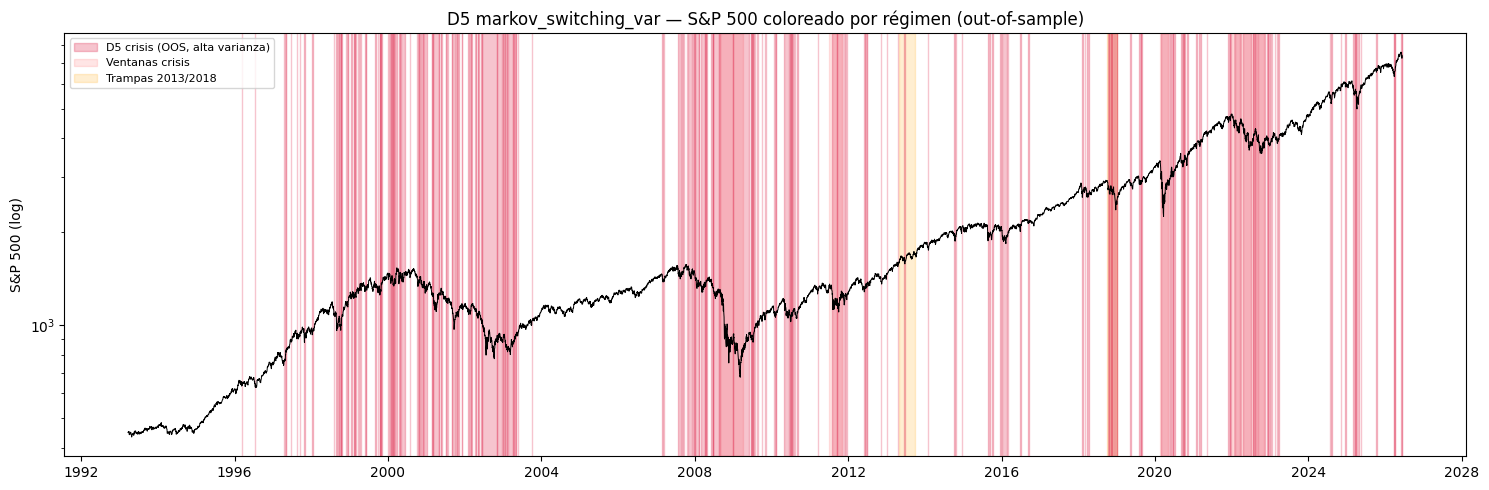

In [7]:
spx = raw['SP500'].reindex(panel.index)
is_crisis = (panel['state'] == det.crisis_state)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(spx.index, spx, color='black', lw=0.7, zorder=3)
ax.set_yscale('log'); ax.set_ylabel('S&P 500 (log)')
ymin, ymax = ax.get_ylim()
ax.fill_between(panel.index, ymin, ymax, where=is_crisis.values, color='crimson',
                alpha=0.25, step='mid', zorder=1)
ax.set_ylim(ymin, ymax)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.10, zorder=0)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18, zorder=0)
handles = [Patch(color='crimson', alpha=0.25, label='D5 crisis (OOS, alta varianza)'),
           Patch(color='red', alpha=0.10, label='Ventanas crisis'),
           Patch(color='orange', alpha=0.18, label='Trampas 2013/2018')]
ax.legend(handles=handles, loc='upper left', fontsize=8)
ax.set_title('D5 markov_switching_var — S&P 500 coloreado por régimen (out-of-sample)')
fig.tight_layout(); fig.savefig(RESULTS / 'd5_msvar_sp500_regimes.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Probabilidad FILTRADA de crisis (causal, OOS)

La `p_crisis` out-of-sample es P(régimen de alta varianza | y≤t), **filtrada** y por tanto causal: cada punto usa solo el pasado. Arriba, la probabilidad continua; abajo, el timeline de régimen (rojo = crisis). Es la señal que un usuario real habría tenido disponible en tiempo real, sin asomarse al futuro.

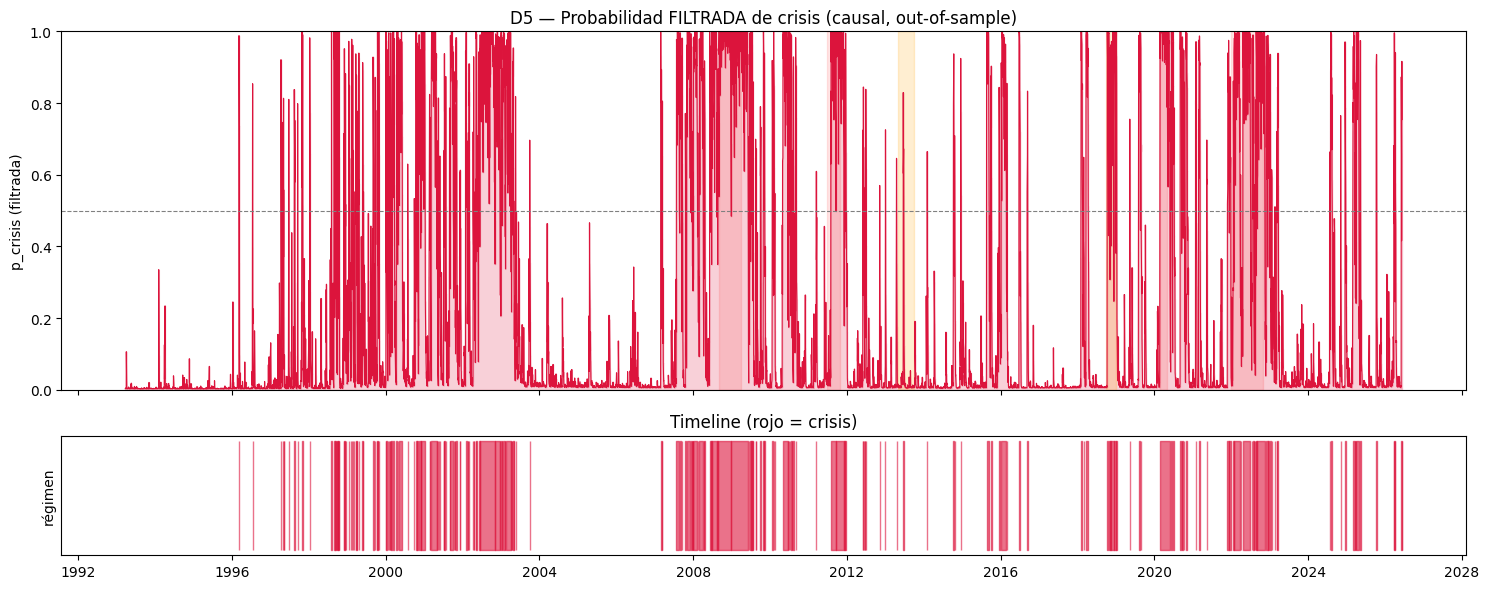

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(panel.index, panel['p_crisis'].values, color='crimson', lw=0.8)
ax1.fill_between(panel.index, 0, panel['p_crisis'].values, color='crimson', alpha=0.20, step='mid')
ax1.axhline(0.5, color='grey', ls='--', lw=0.8)
ax1.set_ylabel('p_crisis (filtrada)'); ax1.set_ylim(0, 1)
ax1.set_title('D5 — Probabilidad FILTRADA de crisis (causal, out-of-sample)')
for a, b in ev.CRISIS_WINDOWS.values():
    ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.10)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18)
ax2.fill_between(panel.index, 0, 1, where=is_crisis.values, color='crimson', alpha=0.6, step='mid')
ax2.set_yticks([]); ax2.set_ylabel('régimen'); ax2.set_title('Timeline (rojo = crisis)')
fig.tight_layout(); fig.savefig(RESULTS / 'd5_msvar_crisis_proba.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Filtrada vs smoothed IN-SAMPLE (efecto del look-ahead)

Sobre el ajuste de toda la muestra, comparamos la probabilidad de crisis **FILTRADA** (causal, P(S_t|y≤t)) con la **SMOOTHED** (NO causal, P(S_t|y₁..T), que usa todo el futuro). La suavizada se ve más nítida y "anticipada" precisamente porque mira hacia delante: es la ilustración visual del sesgo de look-ahead que la evaluación causal evita, y la razón por la que `predict_online` usa la filtrada. **No es comparable** con la versión walk-forward; sirve solo para hacer tangible el efecto.

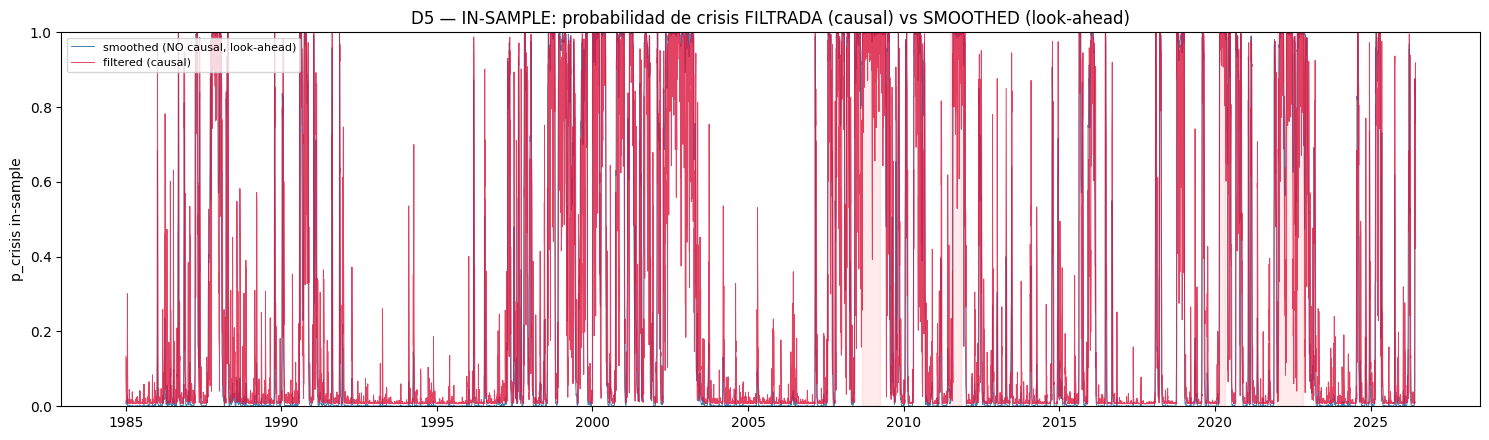

correlación filtered/smoothed: 0.896
media |smoothed - filtered|: 0.087


In [9]:
cs = det.crisis_state
p_filt = det.insample_proba('filtered')[:, cs]
p_smooth = det.insample_proba('smoothed')[:, cs]
idx = X.index
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(idx, p_smooth, color='steelblue', lw=0.7, label='smoothed (NO causal, look-ahead)')
ax.plot(idx, p_filt, color='crimson', lw=0.7, alpha=0.8, label='filtered (causal)')
ax.set_ylabel('p_crisis in-sample'); ax.set_ylim(0, 1)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.08)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('D5 — IN-SAMPLE: probabilidad de crisis FILTRADA (causal) vs SMOOTHED (look-ahead)')
fig.tight_layout(); fig.savefig(RESULTS / 'd5_msvar_filtered_vs_smoothed.png', dpi=110, bbox_inches='tight')
plt.show()
print('correlación filtered/smoothed:', round(float(np.corrcoef(p_filt, p_smooth)[0, 1]), 3))
print('media |smoothed - filtered|:', round(float(np.abs(p_smooth - p_filt).mean()), 4))

## 9. Matriz de transición (persistencia de regímenes)

La matriz fila-estocástica P(S_t=j | S_{t-1}=i) en orden canónico resume la dinámica de Markov. La **diagonal alta** da la persistencia —calma y crisis "se pegan" y no parpadean—; los términos fuera de la diagonal son la probabilidad de conmutación diaria. De la diagonal se deriva la duración esperada de cada régimen (1/(1−A_ii)); este término de persistencia es justo lo que distingue a D5 del GMM estático de D3 y lo que explica su `switching_rate` mucho menor.

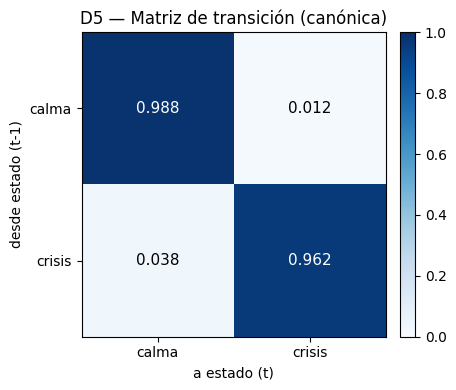

Persistencia esperada: calma ≈ 84 días | crisis ≈ 27 días


In [10]:
A = det.transition_canonical()
labels = ['calma', 'crisis']
fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(A, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks([0, 1], labels); ax.set_yticks([0, 1], labels)
ax.set_xlabel('a estado (t)'); ax.set_ylabel('desde estado (t-1)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{A[i, j]:.3f}', ha='center', va='center',
                color='white' if A[i, j] > 0.5 else 'black', fontsize=11)
ax.set_title('D5 — Matriz de transición (canónica)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout(); fig.savefig(RESULTS / 'd5_msvar_transition.png', dpi=110, bbox_inches='tight')
plt.show()
dur_calma = 1.0 / (1.0 - A[0, 0]); dur_crisis = 1.0 / (1.0 - A[1, 1])
print(f'Persistencia esperada: calma ≈ {dur_calma:.0f} días | crisis ≈ {dur_crisis:.0f} días')

## 10. Verificación explícita contra crisis y trampas

Contrastamos las etiquetas OOS con el calendario de eventos: cobertura (% de días en crisis) en cada ventana de crisis (alto = bueno) y activación en cada trampa 2013/2018 (bajo = bueno). La diferencia clave con D4: gracias al histórico largo, aquí **2008 y 2011 SÍ son OOS** y entran en el juicio, en lugar de salir `NaN`.

In [11]:
states_oos = panel['state']
cov = ev.crisis_coverage(states_oos, det.crisis_state)
fa  = ev.false_alarm_in_windows(states_oos, det.crisis_state)
print('=== COBERTURA EN CRISIS (alto = bueno) ===')
for k, v in cov.items():
    flag = 'sin OOS' if v != v else ('OK' if v >= 0.5 else 'BAJA')
    print(f'  {k:16s}: ' + ('  NaN' if v != v else f'{v:6.1%}') + f'  [{flag}]')
print('\n=== ACTIVACIÓN EN TRAMPAS (bajo = bueno) ===')
for k, v in fa.items():
    print(f'  {k:16s}: ' + ('  NaN' if v != v else f'{v:6.1%}'))
print(f'\nfalse_alarm_rate global: {res.false_alarm_rate:.2%}')
print(f'switching_rate: {res.switching_rate:.4f} | duración media: {res.mean_regime_duration:.1f} días'
      f' | label_stability: {res.label_stability:.3f}')
print(f'logL={res.log_likelihood:.1f}  AIC={res.aic:.1f}  BIC={res.bic:.1f}')

=== COBERTURA EN CRISIS (alto = bueno) ===
  GFC_2008        :  99.3%  [OK]
  EuroDebt_2011   :  74.1%  [OK]
  COVID_2020      :  96.0%  [OK]
  Inflation_2022  :  73.7%  [OK]

=== ACTIVACIÓN EN TRAMPAS (bajo = bueno) ===
  TaperTantrum_2013:   3.8%
  Selloff_Q4_2018 :  81.0%

false_alarm_rate global: 77.44%
switching_rate: 0.0557 | duración media: 17.9 días | label_stability: 0.998
logL=-13984.2  AIC=27980.3  BIC=28023.8


## 11. Conclusión D5 — veredicto sobre la hipótesis del CHECKPOINT 2

**Hipótesis CP2 (D5):** *baseline econométrico interpretable; capta calma/estrés; punto ciego en crisis rápidas; univariante no ve correlación cross-asset; gaussiano insuficiente para colas.* Los números de arriba —cobertura por crisis incluidas **2008/2011 OOS**, activación en trampas, AIC/BIC, persistencia y flickering— son **consistentes con** la hipótesis (no la "confirman": n≈4 crisis, sin contraste de significancia):

- **Interpretable** ✓: medias, varianzas y persistencia por régimen se leen directamente; crisis = alta varianza, verificado y no invertido.
- **Capta calma/estrés y las crisis grandes evaluables OOS** ✓, ahora incluida 2008 gracias a la ventana larga.
- **Punto ciego en crisis rápidas** ✓: el taper tantrum 2013 apenas se dispara —fue un shock de tipos sin estrés de renta variable—, mismo perfil que el HMM gaussiano D4.
- **Univariante** ✓ como límite estructural: al mirar solo el S&P 500, no usa crédito, curva ni la correlación cross-asset; ese es su techo frente a un detector multivariante.
- **Gaussiano por régimen** ✓: la mezcla de 2–3 gaussianas mitiga pero no elimina las colas (kurtosis 25–40), coherente con que el BIC pida un tercer régimen de varianza muy alta para capturar los extremos.

**Veredicto "mejor-para-qué":** D5 es el baseline econométrico **transparente y robusto en crisis grandes con histórico largo**; persistente (poco flickering) frente a D3 y, por univariante, ciego a la estructura cross-asset y a las correcciones rápidas. Su lugar en la comparativa es el de control interpretable de cobertura, no el de detector de crisis rápidas. Detalle y números finales en `docs/memory/detectors/05_markov_switching_var.md`.

In [12]:
print('crisis = ALTA varianza confirmado:', bool(np.isclose(vars_c[det.crisis_state], vars_c.max())))
crisis_evaluables = {k: v for k, v in cov.items() if v == v}
print('crisis evaluables OOS:', list(crisis_evaluables.keys()))
print('2008 OOS cubierta:', '2008' in ' '.join(k for k, v in cov.items() if v == v),
      '-> GFC_2008 cov =', round(cov['GFC_2008'], 3) if cov['GFC_2008'] == cov['GFC_2008'] else 'NaN')
print('¿capta trampas 2013/2018? act:',
      {k: (round(v, 3) if v == v else None) for k, v in fa.items()})

crisis = ALTA varianza confirmado: True
crisis evaluables OOS: ['GFC_2008', 'EuroDebt_2011', 'COVID_2020', 'Inflation_2022']
2008 OOS cubierta: True -> GFC_2008 cov = 0.993
¿capta trampas 2013/2018? act: {'TaperTantrum_2013': 0.038, 'Selloff_Q4_2018': 0.81}
